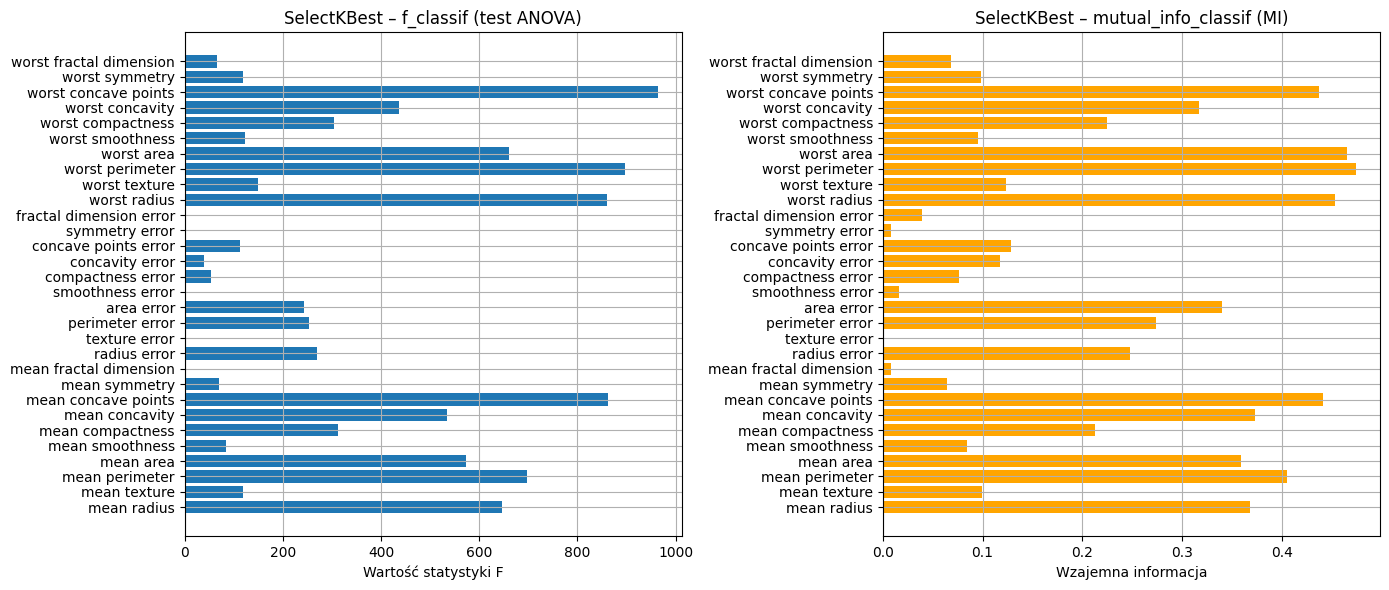

Porównanie cech wybranych przez obie metody:

f_classif:
mean radius, mean perimeter, mean area, mean concavity, mean concave points, worst radius, worst perimeter, worst area, worst concavity, worst concave points

mutual_info_classif:
mean radius, mean perimeter, mean area, mean concavity, mean concave points, area error, worst radius, worst perimeter, worst area, worst concave points

Zapisano pliki:
- X_selectkbest_f.npy / .csv
- X_selectkbest_mi.npy / .csv
- selected_features_comparison.txt


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler

# Wczytaj dane
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Standaryzacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----- METODA 1: f_classif -----
k = 10
selector_f = SelectKBest(score_func=f_classif, k=k)
X_f = selector_f.fit_transform(X_scaled, y)

scores_f = selector_f.scores_
mask_f = selector_f.get_support()
selected_features_f = feature_names[mask_f]

# ----- METODA 2: mutual_info_classif -----
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k)
X_mi = selector_mi.fit_transform(X_scaled, y)

scores_mi = selector_mi.scores_
mask_mi = selector_mi.get_support()
selected_features_mi = feature_names[mask_mi]

# ----- WYKRES PORÓWNAWCZY -----
plt.figure(figsize=(14,6))

# f_classif
plt.subplot(1, 2, 1)
plt.barh(feature_names, scores_f)
plt.title("SelectKBest – f_classif (test ANOVA)")
plt.xlabel("Wartość statystyki F")
plt.grid(True)

# mutual_info_classif
plt.subplot(1, 2, 2)
plt.barh(feature_names, scores_mi, color='orange')
plt.title("SelectKBest – mutual_info_classif (MI)")
plt.xlabel("Wzajemna informacja")
plt.grid(True)

plt.tight_layout()
plt.show()

# ----- PORÓWNANIE CECH -----
print("Porównanie cech wybranych przez obie metody:\n")
print("f_classif:")
print(", ".join(selected_features_f))
print("\nmutual_info_classif:")
print(", ".join(selected_features_mi))

# ----- ZAPIS DO PLIKÓW -----
# Zapis danych z f_classif
np.save("X_selectkbest_f.npy", X_f)
df_f = pd.DataFrame(X_f, columns=selected_features_f)
df_f['target'] = y
df_f.to_csv("X_selectkbest_f.csv", index=False)

# Zapis danych z mutual_info
np.save("X_selectkbest_mi.npy", X_mi)
df_mi = pd.DataFrame(X_mi, columns=selected_features_mi)
df_mi['target'] = y
df_mi.to_csv("X_selectkbest_mi.csv", index=False)

# Zapis list cech do pliku tekstowego
with open("selected_features_comparison.txt", "w") as f:
    f.write("SelectKBest (f_classif):\n")
    for feat in selected_features_f:
        f.write(f"- {feat}\n")
    f.write("\nSelectKBest (mutual_info_classif):\n")
    for feat in selected_features_mi:
        f.write(f"- {feat}\n")

print("\nZapisano pliki:")
print("- X_selectkbest_f.npy / .csv")
print("- X_selectkbest_mi.npy / .csv")
print("- selected_features_comparison.txt")
